# 0. Imports, Constants, Configuration

In [46]:
from pathlib import Path
import random
from pprint import pprint
import logging
from IPython.display import display, Markdown
import os

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

### Loggings:

In [47]:
logging.basicConfig(format="%(levelname)s: %(message)s")
logging.getLogger().setLevel(logging.DEBUG) # to reset logging level in notebooks
logging.getLogger("PIL").setLevel(logging.WARNING) # to avoid PIL debug messages
logging.getLogger("matplotlib").setLevel(logging.WARNING) # same for matplotlib, just in case

---
---
### Colab config

In [48]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [49]:
BASE_DIR = "/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/notebooks"
os.chdir(BASE_DIR)

---
---

In [50]:
Path.cwd()

PosixPath('/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/notebooks')

## Initial configurations

In [51]:
#-------------------------------------------------------------------------------
# Paths
#-------------------------------------------------------------------------------

DATA_DIR = Path("../data/side/data_jpg_crop_576x448").resolve()
print(DATA_DIR, '\n')

CLEAN_DIR_IMG  = DATA_DIR / 'images/clean_train'
print(CLEAN_DIR_IMG, '\n')
CLEAN_DIR_MASK = DATA_DIR / 'masks/clean_train'
print(CLEAN_DIR_MASK, '\n')

# won't be used
DEFECT_DIR_IMG = DATA_DIR / 'defects_test'
print(DEFECT_DIR_IMG, '\n')
DEFECT_DIR_MASK = DATA_DIR / 'masks/defects_test'
print(DEFECT_DIR_MASK, '\n')

#-------------------------------------------------------------------------------
# Constants
#-------------------------------------------------------------------------------

SEED = 42
IMG_SIZE = (576, 448)
# CORRUPTION_FACTOR = 0.5 # Higher → more corruption. 0.5 means the noise will have a stddev of 0.5, which is quite high for pixel values in [0,1]. Adjust as needed.
BATCH_SIZE = 8
EPOCHS = 40
VAL_SPLIT = 0.15
AUTOTUNE = tf.data.AUTOTUNE # -1

VALID_EXTS = {".jpg", ".jpeg", ".png"}
SKIP_DIRS = {'flagged'}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448 

/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train 

/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/masks/clean_train 

/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/defects_test 

/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/masks/defects_test 



---
# 1. Data Preparation
---

<span style='color:yellow'> Before moving on: </span>
> The following functions from `list_files` to `create_dataset` are defined in `data.py` since they are shared between notebooks. However, they are still included here for **pedagogical purposes and to make this notebook self-contained**. They are marked with `--- IGNORE ---` to indicate that they are not part of the core logic of this notebook and can be skipped when reading for understanding the anomaly detection process.

## 1.1 List Paths

In [52]:
# --- IGNORE ---
def list_files(directory: Path, skip_dirs: set[str] | None = None) -> list[Path]:
    """ Returns the list of paths of all the images in the given directory and subdirectories.
    If skip_dirs is not given, no folders will be skipped.
    """
    skip_dirs = skip_dirs or set() # None, set(), [], {}, "" → set()
    files = []
    n = 0
    logging.debug(f"Scanned directories:")
    for root, dirs, filenames in os.walk(directory):
        # Modify 'dirs' in place so certain folders are exluded from the search:
        logging.debug(f'{root}')
        dirs[ : ] = [d for d in dirs if d not in skip_dirs]
        for fl in filenames:
            if Path(fl).suffix.lower() not in VALID_EXTS: # skip non-image files
                n+=1
                continue
            files.append(Path(root) / fl)
    print(('-'*80 + f'\n    {n} invalid-format files were skipped\n' + '-'*80)
          if n > 0 else print('-'*80 + '\n    All images have valid formats\n' + '-'*80))

    files.sort()
    return files

In [53]:
img_paths = list_files(CLEAN_DIR_IMG, skip_dirs=SKIP_DIRS)
print(f'\n{len(img_paths)} clean images where found in {CLEAN_DIR_IMG} directory\n')

mask_paths = list_files(CLEAN_DIR_MASK, skip_dirs=SKIP_DIRS)
print(f'\n{len(mask_paths)} clean masks where found in {CLEAN_DIR_MASK} directory\n')

DEBUG:root:Scanned directories:
DEBUG:root:/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train
DEBUG:root:/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_v2
DEBUG:root:/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_missplaced
DEBUG:root:/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_new
DEBUG:root:/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_v1
DEBUG:root:Scanned directories:
DEBUG:root:/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/masks/clean_train
DEBUG:root:/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/masks/clean_train/clean_missplaced
DEBUG:root:/content/drive/MyDrive/Colab_Not

--------------------------------------------------------------------------------
    All images have valid formats
--------------------------------------------------------------------------------
None

201 clean images where found in /content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train directory



DEBUG:root:/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/masks/clean_train/clean_v1


--------------------------------------------------------------------------------
    All images have valid formats
--------------------------------------------------------------------------------
None

201 clean masks where found in /content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/masks/clean_train directory



### Train and val split:

In [54]:
# --- IGNORE ---
def split_train_val(img_paths : list[Path], mask_paths : list[Path], val_split: float
                    ) -> tuple[list[Path], list[Path], list[Path], list[Path]]:
    '''
    Splits the list of image and mask paths into train and validation sets.
    '''
    # Create and shuffle indices:
    indices = list(range(len(img_paths)))
    random.shuffle(indices)

    # Sort according to indices:
    img_paths = [img_paths[i] for i in indices]
    mask_paths = [mask_paths[i] for i in indices]

    n_val = int(len(img_paths) * val_split)

    # Split into train and validation:
    train_img_paths = img_paths[n_val:]
    train_mask_paths = mask_paths[n_val:]

    val_img_paths = img_paths[:n_val]
    val_mask_paths = mask_paths[:n_val]

    # Sanity check:
    same_order = (img.stem == mask.stem for img, mask in zip(img_paths, mask_paths))
    assert len(img_paths) == len(mask_paths), "Images and masks have different lengths"
    assert same_order, "Images and masks are not in the same order"

    return train_img_paths, train_mask_paths, val_img_paths, val_mask_paths

In [55]:
train_img_paths, train_mask_paths, val_img_paths, val_mask_paths = split_train_val(img_paths, mask_paths, VAL_SPLIT)

print(f'\n{len(train_img_paths)} training images and {len(val_img_paths)} validation images\n')

pprint(img_paths[:10])
print()
pprint(mask_paths[:10])


171 training images and 30 validation images

[PosixPath('/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_missplaced/1W9A3017.jpg'),
 PosixPath('/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_missplaced/bundlecouch.mp4#t=21.4.jpg'),
 PosixPath('/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_missplaced/img_5072.jpg'),
 PosixPath('/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_missplaced/img_5073.jpg'),
 PosixPath('/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_missplaced/img_5074.jpg'),
 PosixPath('/content/drive/MyDrive/Colab_Notebooks/anomaly_detection/data/side/data_jpg_crop_576x448/images/clean_train/clean_missplaced/img_5095.jpg'),
 PosixPath('/content/

## 1.2 Create Dataset

### Load images and masks:
`tf.oi` is the tensorflow module for input/output operations. Is the module of tensorflow for reading, writing, parsing and transforming data:

In [56]:
# --- IGNORE ---
def _load_image_tf(tf_image_path: tf.Tensor) -> tf.Tensor:
    '''
    Loads an image from the given path and preprocesses it for training.
    Only supports JPG images.
    Returns a tensor of shape (H, W, 3) and dtype float32 with pixel values in [0,1].
    '''
    image_bytes = tf.io.read_file(tf_image_path) # read the image file as a bytes string
    image = tf.image.decode_jpeg(image_bytes, channels=3) # decode the bytes string into a tensor of shape (H, W, 3) and dtype uint8
    image = tf.image.convert_image_dtype(image, tf.float32)  # Rescale to [0,1] (better for training)
    tf.debugging.assert_equal(tf.shape(image)[:2], IMG_SIZE) # Debugging: Double check the image size
    return image

In [57]:
# --- IGNORE ---
def _load_mask_tf(tf_mask_path: tf.Tensor) -> tf.Tensor:
    '''
    Loads a mask from the given path and preprocesses it for training (loss function).
    Only supports PNG images.
    Returns a tensor of shape (H, W, 1) and dtype float32 with pixel values in [0,1].
    '''
    mask_bytes = tf.io.read_file(tf_mask_path) # read the image file as a bytes string
    mask = tf.image.decode_png(mask_bytes, channels=1) # decode the bytes string into a tensor of shape (H, W, 1) and dtype uint8
    mask = tf.image.convert_image_dtype(mask, tf.float32)  # Rescale to [0,1] (consistency with the rest of the pipeline)
    tf.debugging.assert_equal(tf.shape(mask)[:2], IMG_SIZE) # Debugging: Double check the image size
    return mask

### Add noise to the images:

In [58]:
# --- IGNORE ---
def _add_mild_corruption(image: tf.Tensor, corruption_factor: float) -> tf.Tensor:
    ''' Adds mild corruption to the given image tensor. Returns a corrupted image tensor of the same shape and dtype as the input, with pixel values in [0,1]. '''
    x = image
    # Mild Gaussian noise
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=corruption_factor, dtype=tf.float32)
    x = x + noise # Add noise. Can push pixels outside [0,1].
    x = tf.clip_by_value(x, 0.0, 1.0) # Ensure pixel values are still in [0,1]. If p > 1 → 1, if p < 0 → 0.

    # Mild brightness variation
    x = tf.image.random_brightness(x, max_delta=0.05)
    x = tf.clip_by_value(x, 0.0, 1.0)

    # Mild contrast variation
    x = tf.image.random_contrast(x, lower=0.95, upper=1.05)
    x = tf.clip_by_value(x, 0.0, 1.0)

    return x

In [59]:
# --- IGNORE ---
def corrupt_clean_mask_from_path(tf_image_path: tf.Tensor,
                                 tf_mask_path: tf.Tensor,
                                 corruption_factor: float,
                                 ) -> tuple[tf.Tensor, tf.Tensor]:
    '''
    Loads the image at the given path, creates a mildly corrupted version of it.
    Loads the mask at the given path.
    Returns the image, currupted image, and mask as tensors.
    '''
    clean = _load_image_tf(tf_image_path)
    corrupted = _add_mild_corruption(clean, corruption_factor)
    mask = _load_mask_tf(tf_mask_path)

    y_true = tf.concat([clean, mask], axis=-1)  # Concat into tensor so it matches with what model.fit() expects. (H, W, c)

    return corrupted, y_true

### Lazy loading and on-the-fly corruption of the images during training:
`tf.data.Dataset` is the main class of the module. It is not a data container but a **data transformation pipeline**. The object `Dataset` is an iterable, processes elements lazily (on-the-fly) as they are requested:
- `map` transforms each element of the dataset **on-the-fly.**
- `batch` groups elements into batches for efficient computation during training.
- `prefetch` optimizes the process. Allows the data pipeline to prepare the next batch while the current batch is being processed by the model, reducing idle time.
    - e.g., CPU prepares data while GPU (or CPU) processes the current batch

Without `tf.data`:
- All the data is loaded in the RAM.
- Data pipelines are typically less efficient.
- No automatic parallelism or overlap between preprocessing and model execution.

<span style='color:yellow'> Note: </span> A `Dataset` behaves similarly to a Python **generator**, but supports parallelism, optimization, and complex transformations

In [60]:
# --- IGNORE ---
def create_dataset(image_paths: list[Path],
                   mask_paths: list[Path],
                   shuffle: bool = True,
                   corruption_factor: float = 0.8) -> tf.data.Dataset:
    '''
    Creates a dataset containing triples of the form (corrupted_image, clean_image, mask).
    '''
    if len(image_paths) != len(mask_paths):
        raise ValueError(f"image_paths and mask_paths must have the same length, "
                         f"got {len(image_paths)} and {len(mask_paths)}.")

    # Create a dataset with the list of tuples of paths (elements will be tf.Tensors tuples):
    lazy_ds = tf.data.Dataset.from_tensor_slices(
        ([str(p) for p in image_paths], [str(p) for p in mask_paths]) # tuples
        )
    # Shuffles (the paths tuples) to ensure random order at each epoch during training:
    lazy_ds = (lazy_ds.shuffle(buffer_size=len(image_paths), seed=SEED)) if shuffle else lazy_ds
    # Apply corruption and loading in parallel to speed up the data pipeline:
    lazy_ds = lazy_ds.map(lambda tf_image_path, tf_mask_path:
        corrupt_clean_mask_from_path(tf_image_path, tf_mask_path, corruption_factor),
        num_parallel_calls=AUTOTUNE)
    # Each element of the dataset is now a tensor tuple: (corrupted_image, packed_clean_mask)

    # Batch the dataset:
    lazy_ds = lazy_ds.batch(BATCH_SIZE)
    # Prefetch to improve performance:
    lazy_ds = lazy_ds.prefetch(AUTOTUNE)

    return lazy_ds

Each element of the dataset is a tensor tuple `(corrupted_image, packed_clean_mask)` -> `((batch, H, W, 3)(batch, H, W, 4))`, where `corrupted_image` is the input and `clean_image` is the target. `clean_image` and `mask` are packed together so that `mask` travels explicitly as part of the target, and thay can be handled accodingly by the loss function.

### Create train and val datasets:

In [61]:
train_ds = create_dataset(train_img_paths, train_mask_paths, shuffle=True,)
val_ds = create_dataset(val_img_paths, val_mask_paths, shuffle=False,)

In [62]:
batch_x, batch_y = next(iter(train_ds))
batch_y.shape

TensorShape([8, 576, 448, 4])

## 1.3 Visualization

Display some examples of the corrupted and clean images from the training dataset:

In [63]:
def show_batch_examples(dataset: tf.data.Dataset, n: int = 3) -> None:
    batch_x, batch_y = next(iter(dataset))
    batch_y = batch_y[:,:,:,:3] # (B, H, W, 4) e.g. (8, 576, 448, 4)

    plt.figure(figsize=(12, 4 * n))
    for i in range(n):
        # Corrupted
        plt.subplot(n, 2, 2 * i + 1) # The 3rd argument is the index of the subplot. +1 means to plot always in the first column.
        plt.imshow(batch_x[i].numpy()) # Convert the tensor to a numpy array for plotting. The pixel values are still in [0,1], but plt.imshow interprets them correctly using the dtype and range. Rescales the data accordingly to [0,255].
        plt.title("Input corrupted")
        plt.axis("off")

        # Clean
        plt.subplot(n, 2, 2 * i + 2) # +2 means to plot always in the second column.
        plt.imshow(batch_y[i].numpy())
        plt.title("Target clean")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [64]:
show_batch_examples(train_ds, n=4)

Output hidden; open in https://colab.research.google.com to view.

---
# 2. Model Definition and Training
---

## 2.1 Define Architecture

### Encoder-decoder convolutional with U-net skip type:

In [65]:
def _conv_block(x: tf.Tensor, filters: int, kernel_size: int = 3) -> tf.Tensor:
    ''' A convolutional block consisting of two Conv2D layers, each followed by
    BatchNormalization and ReLU activation. Returns the output tensor after applying
    the block. '''
    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

In [66]:
def build_unet_dae(input_shape: tuple[int, int, int] = (512, 512, 3)) -> keras.Model:
    ''' Builds a U-Net architecture for a denoising autoencoder. The model takes an input
    image of the specified shape and outputs a denoised image of the same shape. Returns
    the model. '''
    inputs = keras.Input(shape=input_shape)

    # Encoder
    c1 = _conv_block(inputs, 32)
    p1 = layers.MaxPooling2D()(c1)

    c2 = _conv_block(p1, 64)
    p2 = layers.MaxPooling2D()(c2)

    c3 = _conv_block(p2, 128)
    p3 = layers.MaxPooling2D()(c3)

    c4 = _conv_block(p3, 256)
    p4 = layers.MaxPooling2D()(c4)

    # Bottleneck
    bn = _conv_block(p4, 512)

    # Decoder
    u4 = layers.UpSampling2D()(bn)
    u4 = layers.Concatenate()([u4, c4])
    c5 = _conv_block(u4, 256)

    u3 = layers.UpSampling2D()(c5)
    u3 = layers.Concatenate()([u3, c3])
    c6 = _conv_block(u3, 128)

    u2 = layers.UpSampling2D()(c6)
    u2 = layers.Concatenate()([u2, c2])
    c7 = _conv_block(u2, 64)

    u1 = layers.UpSampling2D()(c7)
    u1 = layers.Concatenate()([u1, c1])
    c8 = _conv_block(u1, 32)

    outputs = layers.Conv2D(3, 1, activation="sigmoid", padding="same")(c8)

    model = keras.Model(inputs, outputs, name="unet_dae")
    return model

## 2.2 Loss Function:

>$$
\mathcal{L}(x,y) = \alpha \cdot \text{MAE}(y, \hat{y}) + \beta \cdot (1 - \text{MS-SSIM} (y, \hat{y}))
$$


- **MAE** (Mean absolute error):

    Differences pixel wise.

---

- **SSIM** (Structural Similarity Index):

    Evaluates structural differences by analyzing local windows (typically using a **Gaussian weight**) across the image. Let $x$ and $y$ be corresponding local patches from the original and reconstructed images, respectively. The index compares them based on three components: luminance, contrast, and structure:

    >$$
    SSIM(x,y) = [l(x,y)]^{\alpha} \cdot [c(x,y)]^{\beta} \cdot [s(x,y)]^{\gamma}
    $$
    where $\alpha = \beta = \gamma = 1$ by defualt.

    - **Luminance ($l$)**: Compares the mean intensities of the patches.

        Let $\mu_x$ and $\mu_y$ be the mean values of the patches, then the luminance is given by:
    >$$
        l(x,y) = \frac{2 \mu_x \mu_y + C_1}{\mu_x^2 + \mu_y^2 + C_1}
    $$
    - **Contrast ($c$)**:  Compares how much the pixel values vary, using the standard deviations ($\sigma$) and variances ($\sigma^2$) of the patches
    >$$
        c(x,y) = \frac{2 \sigma_x \sigma_y + C_2}{\sigma_x^2 + \sigma_y^2 + C_2}
    $$
    - **Structure ($s$)**: Compares the inner structure patterns by measuring the correlation between the patches.

        Let $\sigma_{xy}$ be the covariance, then the structure is given by:
    >$$
        s(x,y) = \frac{\sigma_{xy} + C_3}{\sigma_x \sigma_y + C_3}
    $$

    <span style='color:red'> **Observations:** </span>
    - When the parches are similar, $l$, $c$, $s$ tend to be 1.
    - The constant $C$ is there to avoid 0 division.
    - Since structure is measured via covariance, which only captures linear relationships, a window that is too large would fail to capture complex structural patterns. However, at a small enough scale, most image patterns behave **locally linear**, allowing the covariance to effectively represent the structural similarity.

    <span style='color:red'> **Visual Intuition:** </span>

    SSIM rewards features such as:

    - Edge preservation:
        - Ensures an edge remains an edge. **Penalize blurred and smoothed edges**.
    - Texture consistency:
        - Ensures a texture retains its tactile quality. **Penalize textures that have turn into a flat "blob"**
    - Local transitions:
        - Preserve the integrity of local gradients and lighting flow. **Penalizes gradient distortions, ensuring that smooth transitions don't become stepped or irregular.**

    While MSE penalizes any difference between individual pixels equally, SSIM focuses on perceptual similarity, allowing for minor pixel variations as long as the overall structure and context remain intact.

---

- **MS-SSIM** (Multi-Scale SSIM):

    Evaluates SSIM on different scales of the image:


    | Scale    | What it evaluates
    | -------- | ----------
    | Original | details
    | 1/2	   | texture
    | 1/4	   | shapes
    | 1/8	   | global structure

In [67]:
# Registers the loss function. Then, just by importing the module where the loss function is defined, it can be used just as any other loss function.
@tf.keras.utils.register_keras_serializable()
def masked_mae_ssim_loss(y_true: tf.Tensor,
                  y_pred: tf.Tensor,
                  alpha: float = 0.7,
                  beta: float = 0.3) -> tf.Tensor:
    """ Combined MAE + MS-SSIM loss for denoising autoencoder.
    Assumes:
    - The images y_true and y_pred are float tensors
    - values are normalized to [0, 1]
    - shape: (batch, H, W, C)
    """
    # y_true contains both the target and the mask:
    y_targ = y_true[:,:,:,:3] # (batch, H, W, 3)
    y_mask = y_true[:,:,:,3:4] # (batch, H, W, 1)

    y_pred = y_pred * y_mask
    y_targ = y_targ * y_mask

    diff = tf.abs(y_targ - y_pred)
    mae = tf.reduce_sum(diff) / ((tf.reduce_sum(y_mask) * 3.0) + 1e-8) # Take the mean only over the masked pixels (3 channels)

    ssim = tf.reduce_mean(tf.image.ssim(y_targ, y_pred, max_val=1.0))

    loss = alpha * mae + beta * (1.0 - ssim)
    return loss

<span style='color:red'> **Note about the `SSIM` with mask:** </span>

Since the padded regions are set to 0 in both the target and the prediction, they **do not contribute** meaningful reconstruction error. These **identical regions** can artificially **inflate** the `SSIM` score, making the loss look better than it really is. For that reason, `SSIM` is given a smaller weight in this implementation.

In [68]:
@tf.keras.utils.register_keras_serializable()
def masked_mae_unmasked_ssim_loss(y_true: tf.Tensor,
                  y_pred: tf.Tensor,
                  alpha: float = 0.7,
                  beta: float = 0.3) -> tf.Tensor:
    """ Combined MAE + MS-SSIM loss for denoising autoencoder.
    Assumes:
    - The images y_true and y_pred are float tensors
    - values are normalized to [0, 1]
    - shape: (batch, H, W, C)
    """
    # y_true contains both the target and the mask:
    y_targ = y_true[:,:,:,:3] # (batch, H, W, 3)
    y_mask = y_true[:,:,:,3:4] # (batch, H, W, 1)

    # Masked MAE:
    diff = tf.abs(y_targ - y_pred) * y_mask
    mae = tf.reduce_sum(diff) / ((tf.reduce_sum(y_mask) * 3.0) + 1e-8) # Take the mean only over the masked pixels (3 channels)
    # Unmasked SSIM:
    ssim = tf.reduce_mean(tf.image.ssim(y_targ, y_pred, max_val=1.0))

    loss = alpha * mae + beta * (1.0 - ssim)
    return loss

<span style='color:red'> **Note about unmasked `SSIM`**: </span>

Using unmasked `SSIM` preserves the original gray padding instead of introducing black regions via masking. This results in a less abrupt intensity discontinuity at the ROI boundaries, leading to more stable local statistics for `SSIM` near those borders.

### Metrics:

In [69]:
def masked_mae_loss(y_true: tf.Tensor, y_pred: tf.Tensor) -> tf.Tensor:
    y_targ = y_true[:,:,:, :3]
    y_mask = y_true[:,:,:, 3:4]

    diff = tf.abs(y_targ - y_pred) * y_mask
    return tf.reduce_sum(diff) / (tf.reduce_sum(y_mask) * 3.0 + 1e-8)

In [70]:
@tf.keras.utils.register_keras_serializable()
def masked_mae_metric(y_true, y_pred):
    clean = y_true[..., :3]
    mask  = y_true[..., 3:4]

    diff = tf.abs(clean - y_pred) * mask
    return tf.reduce_sum(diff) / (tf.reduce_sum(mask) * 3.0 + 1e-8)

@tf.keras.utils.register_keras_serializable()
def masked_ssim_metric(y_true, y_pred):
    clean = y_true[..., :3]
    mask  = y_true[..., 3:4]

    y_pred_m = y_pred * mask
    clean_m  = clean * mask

    return tf.reduce_mean(tf.image.ssim(clean_m, y_pred_m, max_val=1.0))

@tf.keras.utils.register_keras_serializable()
def unmasked_ssim_metric(y_true, y_pred):
    clean = y_true[..., :3]

    return tf.reduce_mean(tf.image.ssim(clean, y_pred, max_val=1.0))

<span style='color:orange'> **Observation about `SSIM` metric :** </span> Notice that because how it is defined, the closer to 1, the better. Unlike the `SSIM` loss in which the value tends to 0

### Compile:

In [ ]:
model = build_unet_dae(input_shape=(*IMG_SIZE, 3))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=masked_mae_ssim_loss,
    metrics=[masked_mae_metric, masked_ssim_metric,],
    # jit_compile=False, # fix an error. Apparently XLA/JIT has limitations with internal operations used by MS-SSIM
)

model.summary()

Model: "unet_dae"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 576, 448,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 576, 448,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 576, 448,  │        128 │ conv2d_38[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_36 (ReLU)     │ (None, 576, 448,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 576, 448,  │      9,248 │ re_lu_36[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 576, 448,  │        128 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_37 (ReLU)     │ (None, 576, 448,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 288, 224,  │          0 │ re_lu_37[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 288, 224,  │     18,496 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 288, 224,  │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_38 (ReLU)     │ (None, 288, 224,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 288, 224,  │     36,928 │ re_lu_38[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 288, 224,  │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_39 (ReLU)     │ (None, 288, 224,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 144, 112,  │          0 │ re_lu_39[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 144, 112,  │     73,856 │ max_pooling2d_9[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 144, 112,  │        512 │ conv2d_42[0][0] 

 Total params: 7,858,499 (29.98 MB)

 Trainable params: 7,852,611 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)

## 2.3 Training

### Callbacks:

In [ ]:
checkpoint_path = "../.models/v3_1_dae_mae_mask_ssim_unmask.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        min_delta=1e-3,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1,
    ),
    keras.callbacks.TerminateOnNaN(),
]

### Train the model:

In [73]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/40

Epoch 1: val_loss improved from None to 0.38489, saving model to ../.models/v3_1_dae_mae_mask_ssim_unmask.keras

Epoch 1: finished saving model to ../.models/v3_1_dae_mae_mask_ssim_unmask.keras
22/22 - 64s - 3s/step - loss: 0.3888 - masked_mae_metric: 0.1896 - unmasked_ssim_metric: 0.1548 - val_loss: 0.3849 - val_masked_mae_metric: 0.2648 - val_unmasked_ssim_metric: 0.3375 - learning_rate: 1.0000e-04
Epoch 2/40

Epoch 2: val_loss did not improve from 0.38489
22/22 - 20s - 909ms/step - loss: 0.2486 - masked_mae_metric: 0.1162 - unmasked_ssim_metric: 0.4455 - val_loss: 0.4787 - val_masked_mae_metric: 0.3970 - val_unmasked_ssim_metric: 0.3337 - learning_rate: 1.0000e-04
Epoch 3/40

Epoch 3: val_loss did not improve from 0.38489
22/22 - 19s - 875ms/step - loss: 0.1911 - masked_mae_metric: 0.0963 - unmasked_ssim_metric: 0.5908 - val_loss: 0.4952 - val_masked_mae_metric: 0.4230 - val_unmasked_ssim_metric: 0.3393 - learning_rate: 1.0000e-04
Epoch 4/40

Epoch 4: val_loss did not im

## 2.4 History Plot

In [82]:
def plot_history(history: keras.callbacks.History) -> None:
    hist = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training history:\n {Path(checkpoint_path).stem}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [84]:
Path(checkpoint_path).stem

'v3_1_dae_mae_mask_ssim_unmask'

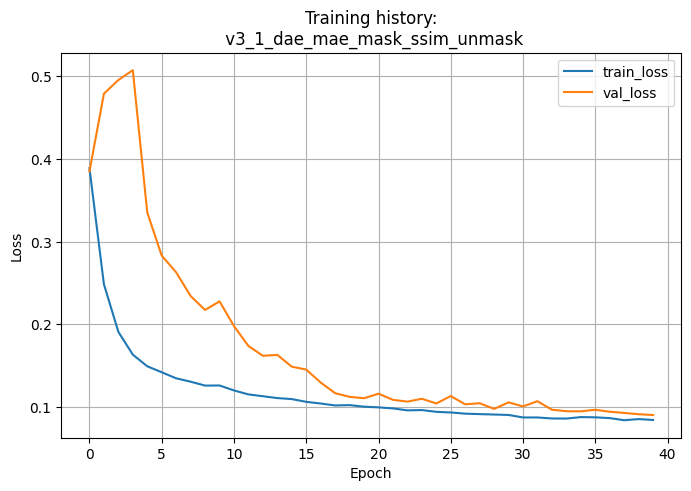

In [83]:
plot_history(history)